# Chapter 11: Sorting Arrays

## 11.1 Fast Sorting in NumPy: np.sort and np.argsort

Python main sorting

In [11]:
# Python list sorting
L = [3, 1, 4, 1, 5, 9, 2, 6]
print(sorted(L))    # [1, 1, 2, 3, 4, 5, 6, 9] (새로운 리스트 반환)

L.sort()            # 원본 리스트를 정렬 (None 반환)
print(L)            # [1, 1, 2, 3, 4, 5, 6, 9]

[1, 1, 2, 3, 4, 5, 6, 9]
[1, 1, 2, 3, 4, 5, 6, 9]


Numpy sorting

In [12]:
import numpy as np

x = np.array([2, 1, 4, 3, 5])
print(np.sort(x))   # [1, 2, 3, 4, 5] (정렬된 복사본 반환)

x.sort()            # 원본 배열을 직접 정렬
print(x)            # [1, 2, 3, 4, 5]

[1 2 3 4 5]
[1 2 3 4 5]


np.argsort() - sorted index return

In [13]:
x = np.array([2, 1, 4, 3, 5])
i = np.argsort(x)
print(i)

# i를 인덱스로 사용하여 정렬된 배렬 얻기
print(x[i])

[1 0 3 2 4]
[1 2 3 4 5]


## 11.2 Sorting Along Rows or Columns

In [14]:
rng = np.random.default_rng(seed=1701)
X = rng.integers(0, 10, (4, 6))
print(X)

# 각 렬을 독립적으로 정렬 (axis=0)
print(np.sort(X, axis=0))

# 각 행을 독립적으로 정렬 (axis=1)
print(np.sort(X, axis=1))

[[9 4 0 3 8 6]
 [3 1 3 7 4 0]
 [2 3 0 0 6 9]
 [4 3 5 5 0 8]]
[[2 1 0 0 0 0]
 [3 3 0 3 4 6]
 [4 3 3 5 6 8]
 [9 4 5 7 8 9]]
[[0 3 4 6 8 9]
 [0 1 3 3 4 7]
 [0 0 2 3 6 9]
 [0 3 4 5 5 8]]


## 11.3 Partial Sorts: Partitioning

In [15]:
import numpy as np

x = np.array([7, 2, 3, 1, 6, 5, 4])

# 가장 작은 3개를 왼쪽에, 나머지는 오른쪽에
print(np.partition(x, 3))
# [2 1 3 4 6 5 7]
#  ↑   ↑     ↑
#  작은 3개  나머지

[1 2 3 4 5 6 7]


Multidimensional Array Partitioning

In [16]:
rng = np.random.default_rng(seed=1701)
X = rng.integers(0, 10, (4, 6))

print(np.partition(X, 2, axis=1))

[[0 3 4 6 8 9]
 [0 1 3 3 4 7]
 [0 0 2 3 6 9]
 [0 3 4 5 5 8]]


## 11.4 Example: k-Nearest Neighbors

Generating 10 random points on a 2D plane

[[0.4020733  0.30563311]
 [0.67668051 0.15821208]
 [0.79247763 0.09419469]
 [0.36753944 0.06388928]
 [0.96431608 0.35200998]
 [0.54550343 0.88597945]
 [0.57016965 0.26614394]
 [0.8170382  0.55906652]
 [0.06387035 0.84877751]
 [0.89414484 0.18920785]]


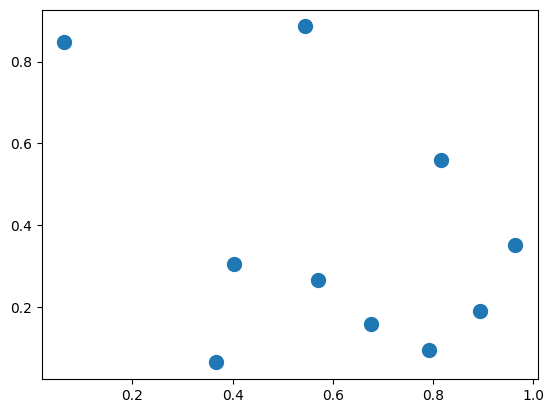

In [23]:
rng = np.random.default_rng(seed=1701)

X = rng.random((10, 2))
print(X)

%matplotlib inline
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], s=100);

Calculating distances between all points

In [18]:
# Broadcasting 사용한 거리 행렬 계산
dist_sq = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=-1)

print(dist_sq)
# 대각선은 자기 자신과의 거리이므로 0
print(dist_sq.diagonal())   # [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

[[0.         0.09714208 0.19712175 0.05963267 0.31826777 0.35737407
  0.02981578 0.23642436 0.40938707 0.25568925]
 [0.09714208 0.         0.0175072  0.10446499 0.12029185 0.54685277
  0.02299385 0.18038456 0.85241691 0.04825147]
 [0.19712175 0.0175072  0.         0.18149088 0.09599718 0.68791936
  0.07898738 0.21670904 1.1002638  0.01936372]
 [0.05963267 0.10446499 0.18149088 0.         0.4391559  0.70750342
  0.08196595 0.44724963 0.70826445 0.29301799]
 [0.31826777 0.12029185 0.09599718 0.4391559  0.         0.46052744
  0.16272439 0.06456318 1.0575805  0.03142854]
 [0.35737407 0.54685277 0.68791936 0.70750342 0.46052744 0.
  0.38480447 0.1806032  0.23335441 0.60704149]
 [0.02981578 0.02299385 0.07898738 0.08196595 0.16272439 0.38480447
  0.         0.14674771 0.59580085 0.11087909]
 [0.23642436 0.18038456 0.21670904 0.44724963 0.06456318 0.1806032
  0.14674771 0.         0.65119427 0.14274086]
 [0.40938707 0.85241691 1.1002638  0.70826445 1.0575805  0.23335441
  0.59580085 0.651194

Finding nearest neighbors

In [19]:
# 각 행을 정렬하여 가장 가까운 거리의 인덱스찾기
nearest = np.argsort(dist_sq, axis=1)
print(nearest)

[[0 6 3 1 2 7 9 4 5 8]
 [1 2 6 9 0 3 4 7 5 8]
 [2 1 9 6 4 3 0 7 5 8]
 [3 0 6 1 2 9 4 7 5 8]
 [4 9 7 2 1 6 0 3 5 8]
 [5 7 8 0 6 4 1 9 2 3]
 [6 1 0 2 3 9 7 4 5 8]
 [7 4 9 6 1 5 2 0 3 8]
 [8 5 0 6 7 3 1 4 2 9]
 [9 2 4 1 6 7 0 3 5 8]]


k-nearest neighbors (k=2)

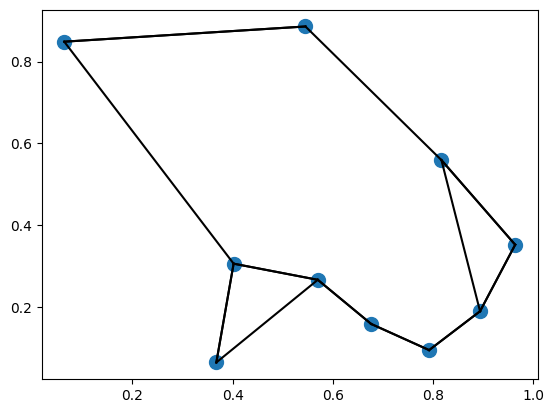

In [ ]:
plt.scatter(X[:, 0], X[:, 1], s=100)
K = 2
nearest_partition = np.argpartition(dist_sq, K + 1, axis=1)

# Visualization - connecting 2 points which nearest from each point
for i in range(X.shape[0]):
    for j in nearest_partition[i, :K+1]:
        # plot a line from X[i] to X[j]
        # use some zip magic to make it happen:
        plt.plot(*zip(X[j], X[i]), color='black')